In [1]:
from src.dataset import DigitAnomalyDataset
from src.encoders import PCAAngleEncoder, AmplitudeEncoder
from src.feature_map import AngleFeatureMap, AmplitudeFeatureMap
from src.kernel import FidelityQuantumKernel, ClassicalRBFKernel
from src.models import OneClassSVMAnomalyModel
from src.anomaly_eval import AnomalyEvaluator
from src.visualizer import AnomalyVisualizer
from src.experiment import QuantumAnomalyExperiment
import pandas as pd

In [2]:
def run_all_four_methods(
    dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    threshold_strategy="expected_fraction",
    verbose=False,
    plot_best=False,
    backend=None
):
    """
    Run all 4 combinations:

        1. PCA encoder       + quantum angle kernel
        2. Amplitude encoder + quantum fidelity kernel
        3. PCA encoder       + classical RBF kernel
        4. Amplitude encoder + classical RBF kernel

    Returns
    -------
    comparison : pandas.DataFrame
        Summary table of metrics.

    results : dict
        Full result dictionaries for each method.

    experiments : dict
        Experiment objects, useful for plotting/debugging.
    """

    methods = {
        "PCA + Quantum Angle Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": FidelityQuantumKernel(
                feature_map=AngleFeatureMap(reps=reps),backend=backend
            ),
        },

        "Amplitude + Quantum Fidelity Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": FidelityQuantumKernel(
                feature_map=AmplitudeFeatureMap(),backend=backend
            ),
        },

        "PCA + Classical RBF Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },

        "Amplitude + Classical RBF Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },
    }

    results = {}
    experiments = {}
    rows = []

    for method_name, components in methods.items():
        exp = QuantumAnomalyExperiment(
            name=method_name,
            dataset=dataset,
            encoder=components["encoder"],
            kernel=components["kernel"],
            model=OneClassSVMAnomalyModel(nu=nu),
            evaluator=AnomalyEvaluator(threshold_strategy=threshold_strategy),
            visualizer=AnomalyVisualizer(),
        )

        result = exp.run(verbose=verbose)

        results[method_name] = result
        experiments[method_name] = exp

        metrics = result["metrics"]
        encoder_info = result.get("encoder_info", {})
        kernel_info = result.get("kernel_info", {})

        row = {
            "method": method_name,
            "encoder": encoder_info.get("type", "unknown"),
            "kernel": kernel_info.get("type", "unknown"),
            "auc": metrics["auc"],
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "threshold": metrics["threshold"],
        }

        if encoder_info.get("type") == "pca_angle":
            row["encoded_dim"] = encoder_info.get("n_components")
            row["qubits_or_features"] = encoder_info.get("n_components")
            row["explained_variance"] = encoder_info.get("total_explained_variance")

        elif encoder_info.get("type") == "amplitude":
            row["encoded_dim"] = encoder_info.get("state_dim")
            row["qubits_or_features"] = encoder_info.get("n_qubits")
            row["explained_variance"] = None

        else:
            row["encoded_dim"] = None
            row["qubits_or_features"] = None
            row["explained_variance"] = None

        rows.append(row)

    comparison = pd.DataFrame(rows)
    comparison = comparison.sort_values("auc", ascending=False).reset_index(drop=True)

    print("\n===== Comparison Table =====")
    display(comparison)

    if plot_best:
        best_method = comparison.iloc[0]["method"]
        print(f"\nPlotting best method: {best_method}")
        experiments[best_method].plot_results()

    return comparison, results, experiments

In [ ]:
from src.backend import get_ibm_backend
from qiskit_ibm_runtime import Session

with Session(backend=get_ibm_backend()) as session:
    dataset = DigitAnomalyDataset(
        normal_digit=0,
        anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
        n_train_normal=10,
        n_test_normal=10,
        n_test_anomaly=10,
        random_state=7,
    )
    
    comparison, results, experiments = run_all_four_methods(
        dataset=dataset,
        pca_components=4,
        reps=2,
        nu=0.1,
        verbose=False,
        plot_best=False,
        backend = session
    )

qiskit_runtime_service.__init__:WARNING:2026-06-02 13:53:36,528: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:36,659: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:37,169: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 13:53:40,768: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:41,097: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:41,871: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 13:53:45,922: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:46,253: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 13:53:46,673: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


...

Selected backend: ibm_quebec
[[0.002 0.04  0.032 0.046 0.    0.034 0.09  0.134 0.012 0.   ]
 [0.    0.028 0.052 0.014 0.    0.018 0.164 0.02  0.    0.   ]
 [0.    0.012 0.004 0.026 0.    0.004 0.028 0.022 0.    0.   ]
 [0.    0.008 0.004 0.014 0.    0.032 0.028 0.074 0.    0.   ]
 [0.    0.002 0.002 0.    0.016 0.    0.    0.002 0.016 0.006]
 [0.    0.132 0.054 0.028 0.    0.11  0.12  0.03  0.    0.   ]
 [0.002 0.03  0.032 0.02  0.    0.016 0.02  0.028 0.    0.   ]
 [0.004 0.018 0.044 0.01  0.    0.1   0.012 0.028 0.    0.   ]
 [0.    0.042 0.028 0.04  0.    0.048 0.054 0.072 0.    0.   ]
 [0.    0.012 0.076 0.004 0.    0.06  0.048 0.014 0.    0.   ]
 [0.    0.038 0.064 0.014 0.    0.01  0.03  0.022 0.    0.   ]
 [0.008 0.    0.    0.    0.002 0.    0.    0.014 0.    0.006]
 [0.    0.    0.002 0.    0.022 0.    0.002 0.012 0.03  0.002]
 [0.002 0.056 0.018 0.006 0.    0.066 0.022 0.032 0.006 0.   ]
 [0.002 0.038 0.024 0.026 0.    0.034 0.03  0.    0.    0.   ]
 [0.002 0.024 0.042 0.008 

qiskit_runtime_service.__init__:WARNING:2026-06-02 14:44:41,654: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 14:44:41,805: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 14:44:42,253: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 14:44:46,730: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 14:44:46,846: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 14:44:47,540: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


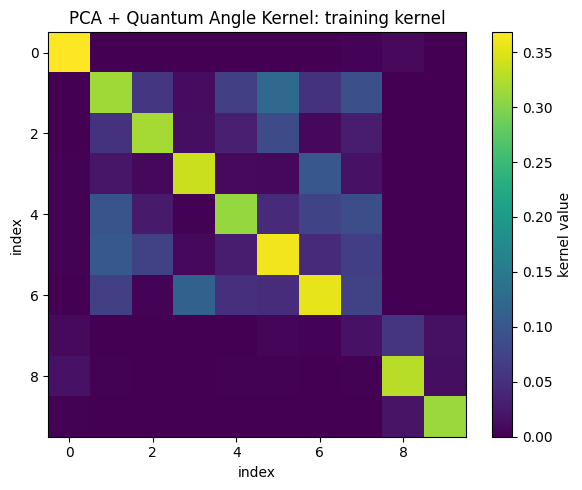

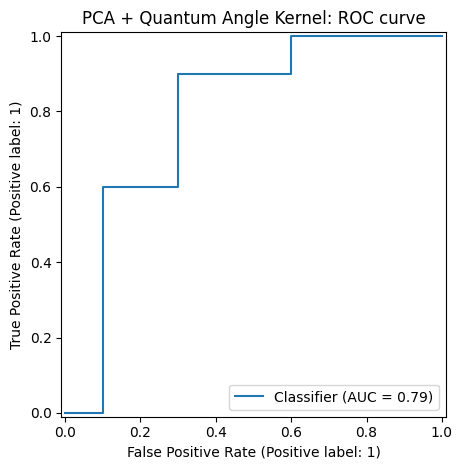

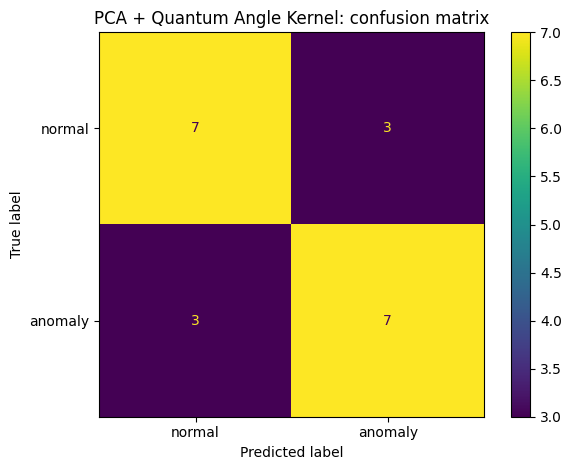

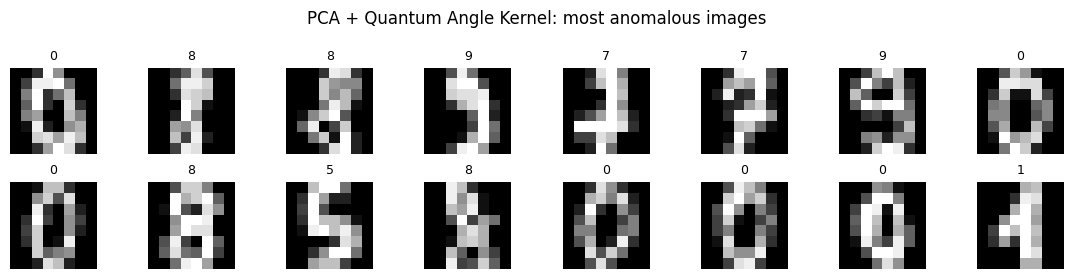

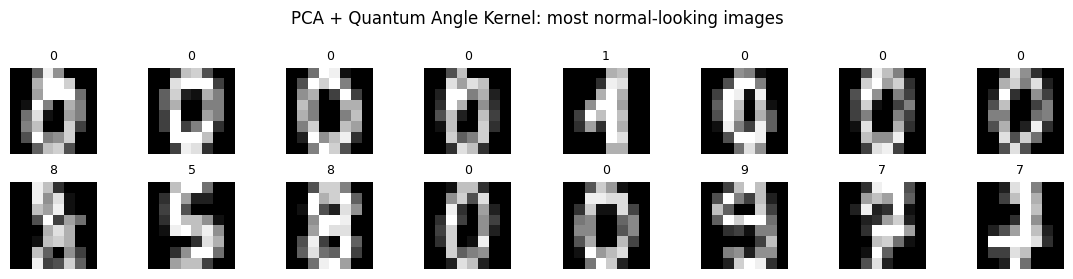

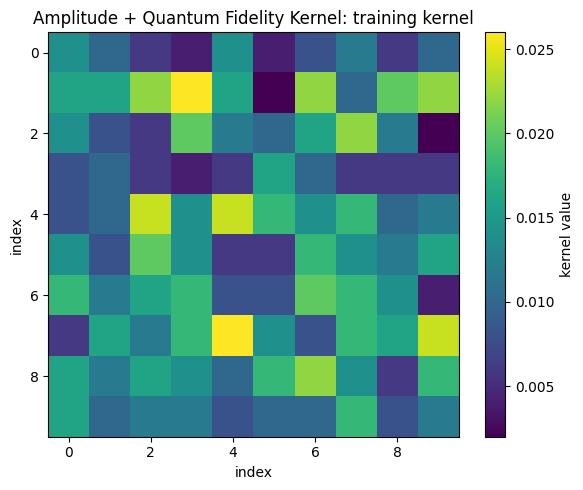

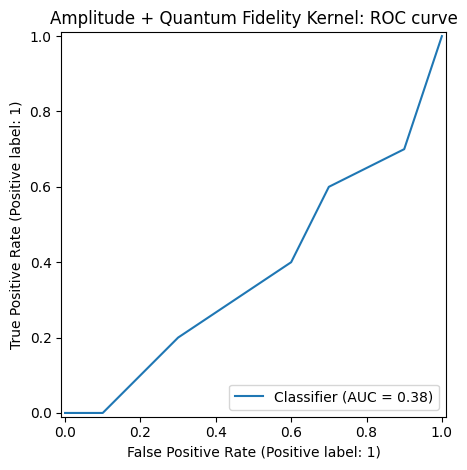

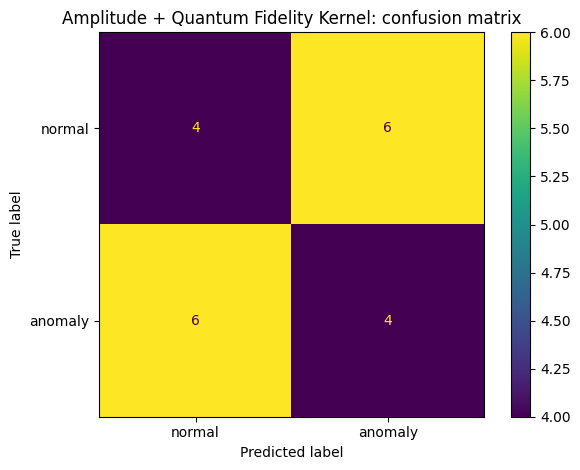

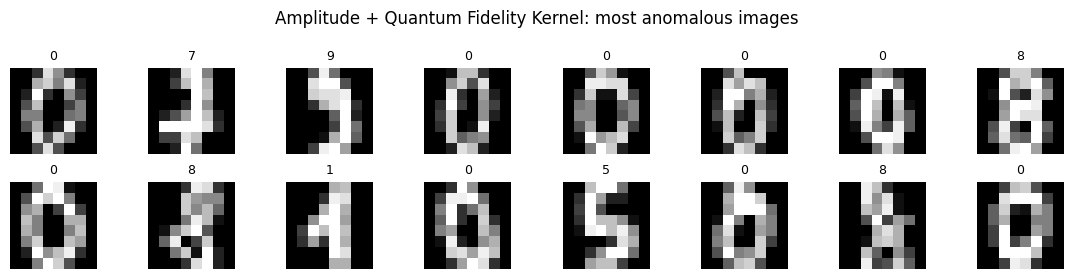

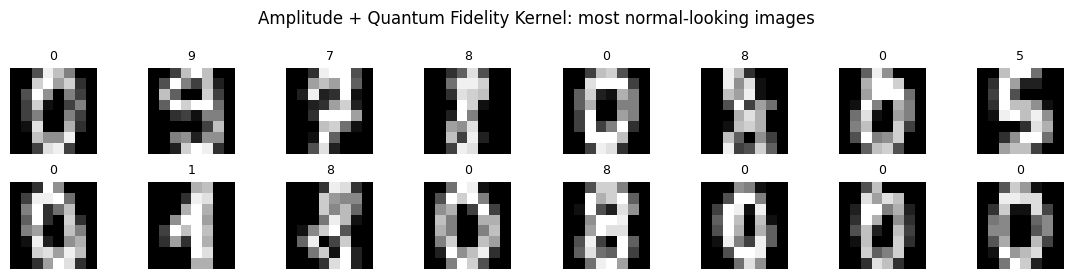

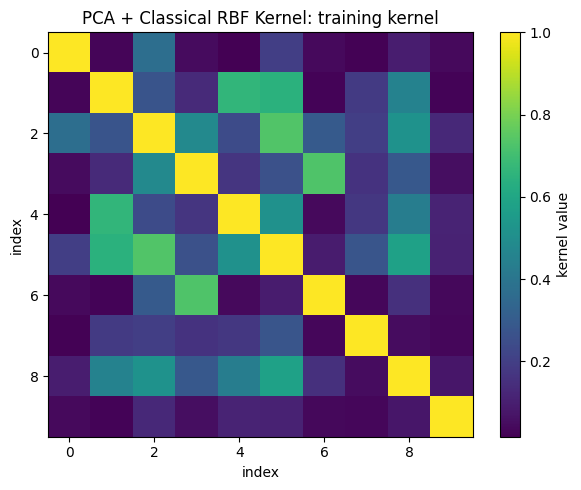

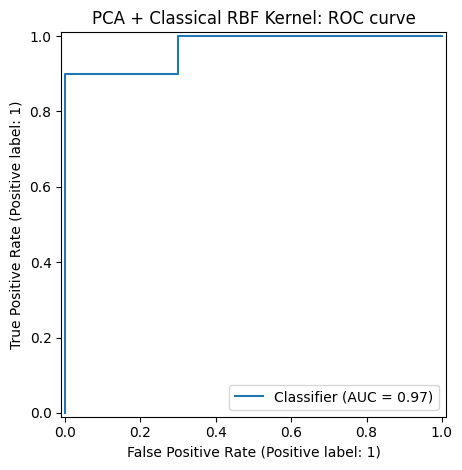

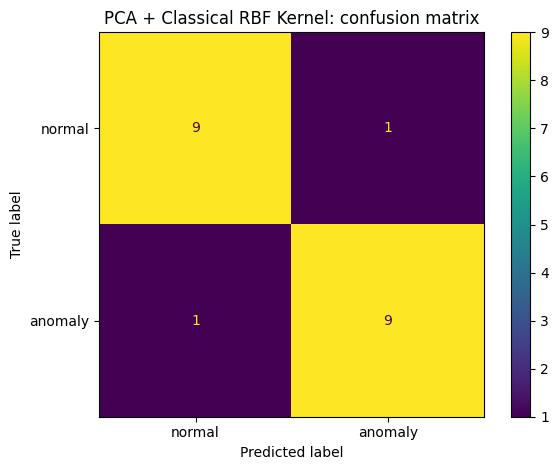

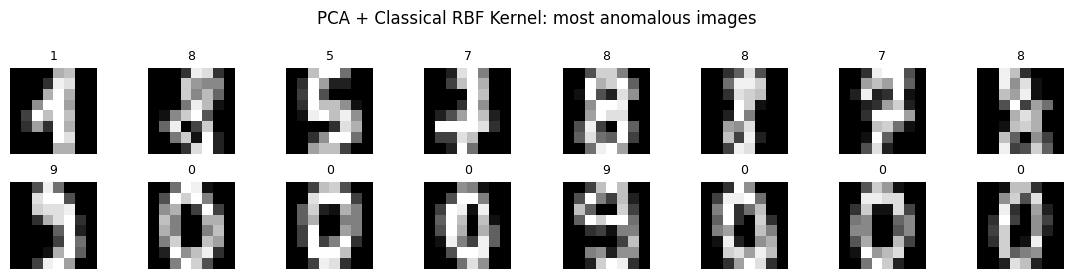

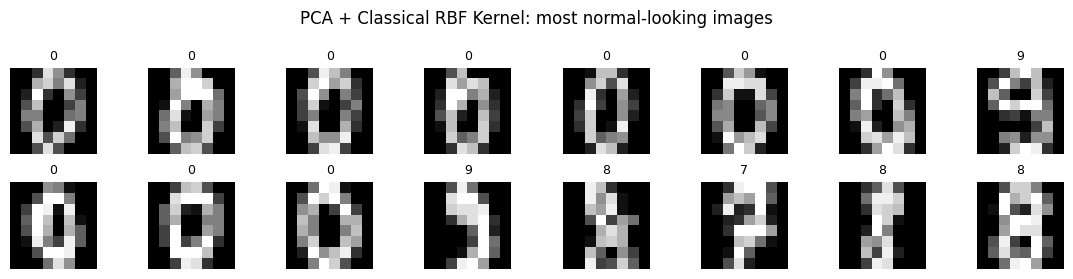

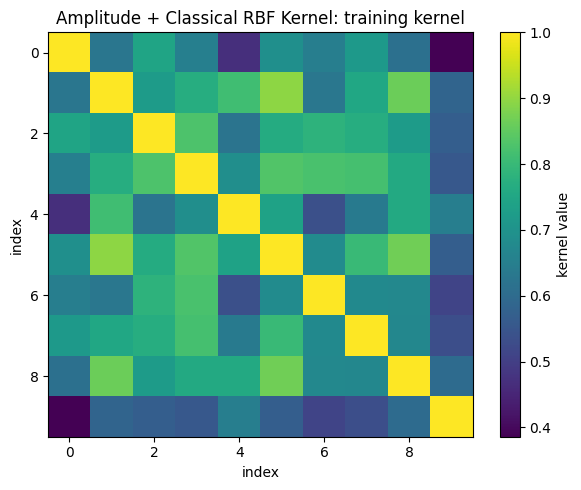

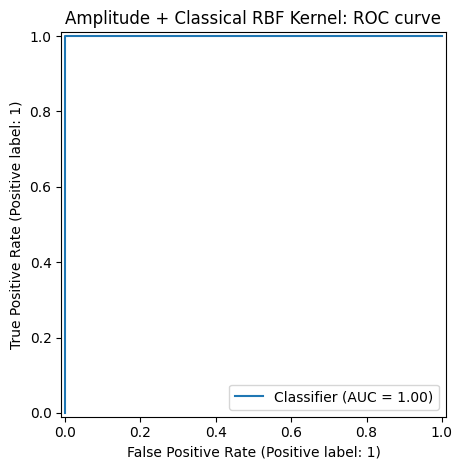

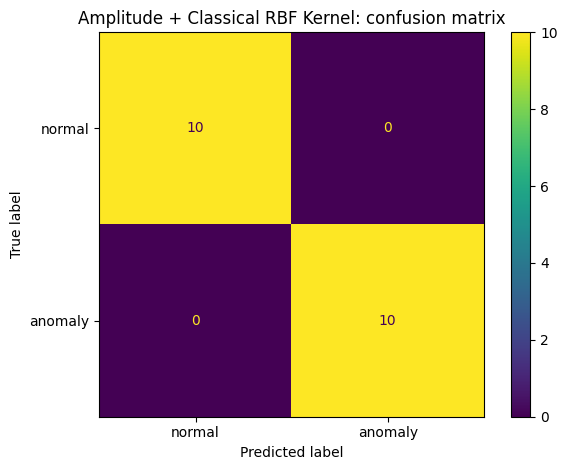

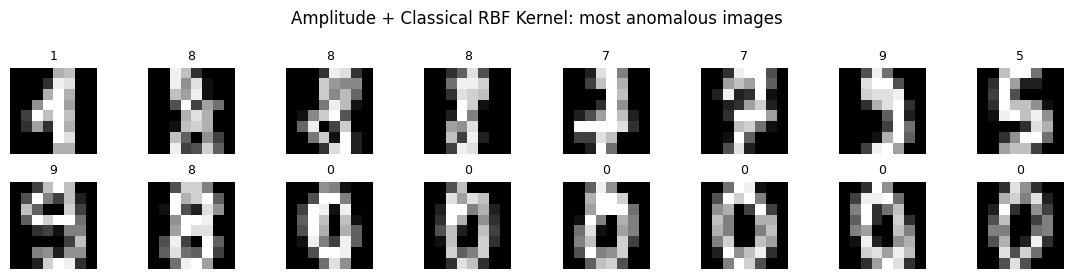

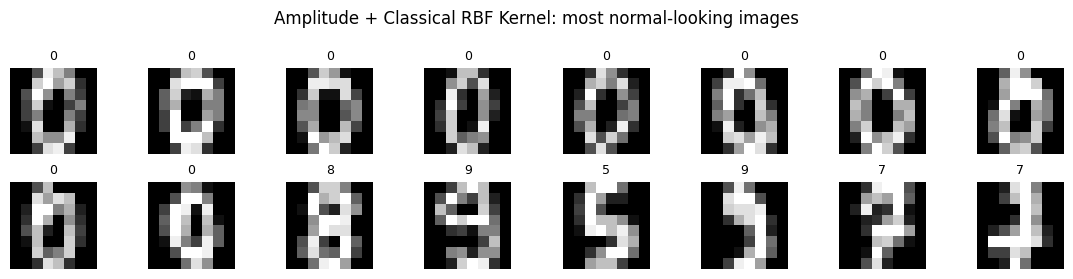

In [7]:
for k in experiments.keys():
    experiments[k].plot_results()

In [8]:
print(results['PCA + Quantum Angle Kernel']["scores"])

[-0.05944122  0.00452981  0.01018337 -0.01852681  0.02174326 -0.00639643
  0.00470139  0.00313342 -0.02271609  0.00964159  0.00610794  0.0169156
  0.01495896  0.00169408  0.01946716  0.01751839  0.02027398  0.00563986
  0.01584708  0.00828521]
